In [16]:
import os
import re
import numpy as np
import pickle
import jax.numpy as jnp
import jax
from utils import find_recipe_in_batch, plot_recipe
from calculate_sds import obj_inclusion_exclusion, find_recipe_repetitions
sampling_batch_size = 10000

In [18]:
seed = 42
criteria = [['egg', 1], ['oat', 1], ['yogurt', 1], ['other cheese', 1], ['onion', 1]]
indices = obj_inclusion_exclusion(seed, criteria)
find_recipe_repetitions(seed, indices, output_fname=f"repeat_counts_ellen_custom_rng_{seed}.txt"); 

Found 231 recipes that match the provided criteria
Loaded 230 recipes into memory.
Finished finding repeat counts for 0/231 recipes
Finished finding repeat counts for 100/231 recipes
Finished finding repeat counts for 200/231 recipes
Saved zero counts and indices to params/repeat_counts_ellen_custom_rng_42.txt


Searching for burgers containing: egg, oat, yogurt, other cheese, onion
Number of samples containing these criteria in the first 1 million:  231
The most repeated recipe:
Repeated 223.0 times
Repeated 223.0 times
Repeated 223.0 times


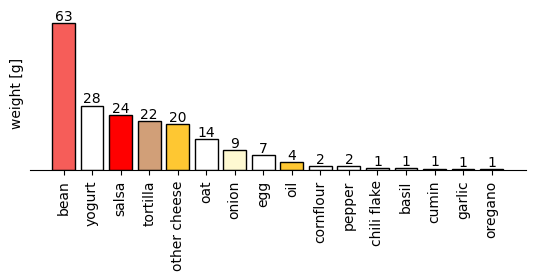

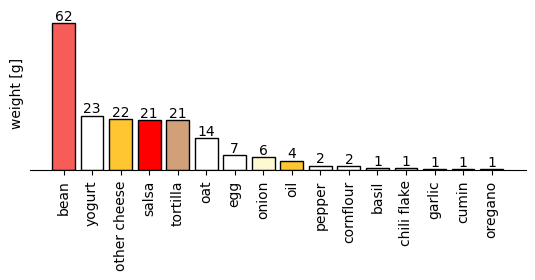

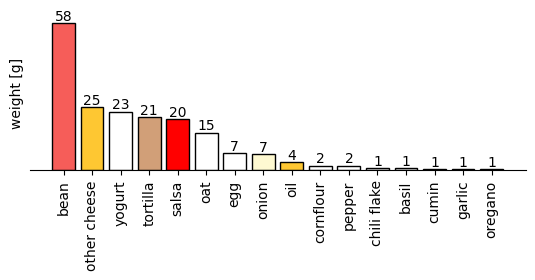

In [19]:
indices, repeat_counts = np.loadtxt('params/repeat_counts_ellen_custom_rng_42.txt').T

print('Searching for burgers containing: egg, oat, yogurt, other cheese, onion')
print('Number of samples containing these criteria in the first 1 million: ', len(indices))

print('The most repeated recipe:')
idx_sorted = np.argsort(repeat_counts)[::-1]

for i in [0,1,2]:
    print(f'Repeated {repeat_counts[idx_sorted[i]]} times')
    idx_recipe = indices[idx_sorted[i]]
    recipe = find_recipe_in_batch(idx_recipe)
    plot_recipe(recipe); 


In [14]:
# search in the training data
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)

In [27]:
mask = np.ones(len(recipes), dtype=bool)
for name, criterion in criteria:
    idx = np.where(ingr_names == name)
    if criterion == 0:
        mask &= np.squeeze(recipes[:, idx] == 0)
    elif criterion == 1:
        mask &= np.squeeze(recipes[:, idx] > 0)
batch_indices = np.squeeze(np.argwhere(mask)).reshape([-1,])
print(len(batch_indices))

1


(<Figure size 640x200 with 1 Axes>, <Axes: ylabel='weight [g]'>)

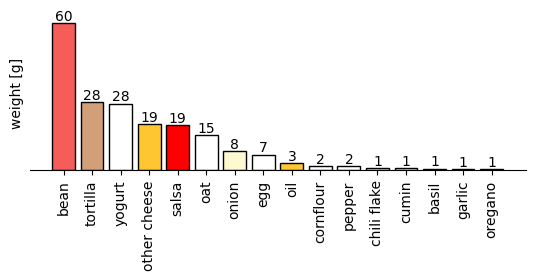

In [28]:
plot_recipe(recipes[batch_indices[0]])

In [41]:
with open('data/burgers_step5.pkl', 'rb') as f:
    ingr_data, burgers = pickle.load(f)
burgers = burgers.drop(burgers.index[30]) # drop row 30, because the same was done in '4_dataprep_2_burgers.ipynb'

In [42]:
recipe = burgers.iloc[batch_indices[0]]

Name                                             Flavor Full Black Bean Burgers
Description                   When in the mood for a veggie burger this is a...
RecipeIngredientQuantities    c("2", "1", "2", "1 1/2", "2", "1", "2", "2", ...
RecipeIngredientParts         c("black beans", "onion", "garlic cloves", "dr...
AggregatedRating                                                            NaN
ReviewCount                                                                 NaN
Calories                                                                  393.6
FatContent                                                                 14.6
SaturatedFatContent                                                         2.5
CholesterolContent                                                        105.8
SodiumContent                                                              79.5
CarbohydrateContent                                                        50.4
FiberContent                            

In [43]:
recipe = burgers.iloc[batch_indices[0]]

In [48]:
print('Name: ', recipe.Name)
print('Description: ', recipe.Description)
print('Ingredients: ', recipe.RecipeIngredientParts)
print('Instructions: ', recipe.RecipeInstructions)

Name:  Flavor Full Black Bean Burgers
Description:  When in the mood for a veggie burger this is a must!!! 
Kids loved them and ate every single bit of it.
Love to hear what y'all think, leave a comment!
Ingredients:  c("black beans", "onion", "garlic cloves", "dry basil", "dried oregano", "ground cumin", "chili powder", "eggs", "cornflour", "cheese", "corn tortilla", "salsa", "plain yogurt")
Instructions:  c("Put the onions, garlic, basil, oregano, cumin, chili powder and eggs in your food processor and chop finely.", "Add the drained beans and the flour and then Pulse for just a few seconds to break the beans but if you like your burger to still have a texture don't over do it.", "Then add the oatmeal and mix w/ a spatula, and let it rest for 5 minutes to let the oatmeal soak all the extra fluid.", "Divide into 6-8 equal portions according to your preferences. And form into patties.", "Heat oil on a pan and fry them.", 
"Serve on a corn tortilla, topped with Shredded Cheese, salsa an

In [52]:
recipe.ingredients_raw

'["2 (15   ounce) cans   black beans, drained, I prefer Goya brand ","1   large    onion, chopped ","2       garlic cloves, chopped ","1 1/2  tablespoons    dry basil","2   teaspoons    dried oregano","1   tablespoon    ground cumin","2   tablespoons    chili powder","2       eggs","3   tablespoons    cornflour (Maseca brand)","2/3  cup    instant oatmeal","  salt and pepper","3   tablespoons    oil (I prefer Olive Oil)"," shredded cheese","  corn tortilla","  salsa","  plain yogurt (Sour Cream)"]'